# 🔍 Exploratory Data Analysis — Employee Attrition

## Vad är EDA?
EDA (Exploratory Data Analysis) är det **första steget i alla ML-projekt**.
Innan vi tränar någon modell måste vi förstå vårt dataset.

Tänk så här: innan du bakar en kaka måste du titta i skafferiet —
vad har du? Räcker mjölet? Är äggen färska? EDA är precis det — vi
kikar i "skafferiet" och ser vad vi har att jobba med.

Vi undersöker:
- Hur ser data ut?
- Finns det saknade värden?
- Hur är variablerna fördelade?
- Vilka faktorer verkar hänga ihop med att en anställd slutar?

## Dataset
Vi använder **IBM HR Analytics Employee Attrition**-datasetet från Kaggle.

| Egenskap | Värde |
|---|---|
| Antal rader | 1 470 |
| Antal kolumner | 35 |
| Target | `Attrition` (Yes / No) |
| Klassobalans | ~16 % Yes, ~84 % No |

## Mål med denna notebook
1. Ladda och inspektera rådata
2. Hitta konstanta kolumner och saknade värden
3. Visualisera klassfördelningen (klassobalansen)
4. Utforska numeriska och kategoriska features
5. Hitta vilka features som verkar starkast kopplade till attrition
6. Visualisera korrelationsmatrisen
7. Sammanfatta viktiga fynd inför modellering

In [1]:
# ── Imports ────────────────────────────────────────────────────────────────────
import sys
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# ── Inställningar ──────────────────────────────────────────────────────────────
RAW_PATH    = "../data/WA_Fn-UseC_-HR-Employee-Attrition.csv"
FIGURES_DIR = "../outputs/figures"
TARGET      = "Attrition"

os.makedirs(FIGURES_DIR, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.dpi":     120,
    "figure.figsize": (10, 5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
})

print("✅ Imports och konfiguration klar!")
print(f"   Datafil  : {RAW_PATH}")
print(f"   Output   : {FIGURES_DIR}")

✅ Imports och konfiguration klar!
   Datafil  : ../data/WA_Fn-UseC_-HR-Employee-Attrition.csv
   Output   : ../outputs/figures


## 1. Ladda rådata

Vi börjar med att läsa in CSV-filen och titta på hur rådata ser ut —
**innan** vi gjort någon rensning eller förändring.

Vi undersöker:
- Hur många rader och kolumner finns det?
- Vilka datatyper har varje kolumn?
- Hur ser de första raderna ut?

In [2]:
# ── Ladda rådata ───────────────────────────────────────────────────────────────
df = pd.read_csv(RAW_PATH)

print(f"Shape  : {df.shape[0]:,} rader × {df.shape[1]} kolumner")
print(f"Minne  : {df.memory_usage(deep=True).sum() / 1024:.1f} KB\n")

display(df.head())

Shape  : 1,470 rader × 35 kolumner
Minne  : 1040.5 KB



,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


**Vad ser vi?**

- Datasetet har **1 470 rader och 35 kolumner** — lagom stort för ML
- `Attrition` (vår target) är text: `"Yes"` eller `"No"` — kodas om till 1/0 senare
- Redan nu syns `EmployeeCount = 1` på alla rader — trolig konstant kolumn
- Tabellen är trunkerad (`...`) — det finns fler kolumner än vad som visas

## 2. Datakvalitet — typer, saknade värden & konstanter

Nu gräver vi lite djupare i datasetet. Vi vill veta:

- Vilken **datatyp** har varje kolumn? (siffror, text, osv.)
- Finns det **saknade värden** (tomma rutor)?
- Finns det **konstanta kolumner** — alltså kolumner där
  alla rader har exakt samma värde?

Konstanta kolumner är som en termometer som alltid visar 37° —
den ger oss ingen information alls och kan tas bort.

In [3]:
# ── Datatyper & saknade värden ─────────────────────────────────────────────────
info = pd.DataFrame({
    "dtype":    df.dtypes,
    "non_null": df.notna().sum(),
    "null":     df.isna().sum(),
    "null_%":   (df.isna().mean() * 100).round(2),
    "n_unique": df.nunique(),
})

display(info)

# ── Konstanta kolumner ─────────────────────────────────────────────────────────
constant_cols = [col for col in df.columns if df[col].nunique() == 1]
print(f"\nKonstanta kolumner ({len(constant_cols)}) : {constant_cols}")
for col in constant_cols:
    print(f"  {col} → alltid = {df[col].iloc[0]}")

,dtype,non_null,null,null_%,n_unique
Age,int64,1470,0,0.0,43
Attrition,str,1470,0,0.0,2
BusinessTravel,str,1470,0,0.0,3
DailyRate,int64,1470,0,0.0,886
Department,str,1470,0,0.0,3
DistanceFromHome,int64,1470,0,0.0,29
Education,int64,1470,0,0.0,5
EducationField,str,1470,0,0.0,6
EmployeeCount,int64,1470,0,0.0,1
EmployeeNumber,int64,1470,0,0.0,1470



Konstanta kolumner (3) : ['EmployeeCount', 'Over18', 'StandardHours']
  EmployeeCount → alltid = 1
  Over18 → alltid = Y
  StandardHours → alltid = 80


**Vad ser vi?**

- ✅ **Inga saknade värden** — alla 1 470 rader är kompletta, ingen imputation behövs
- ✅ **Inga dubbletter** — varje rad är en unik anställd
- ⚠️ **3 konstanta kolumner** hittades — de ger modellen noll information:

| Kolumn | Värde | Varför oanvändbar |
|---|---|---|
| `EmployeeCount` | alltid `1` | Alla är anställda — säger ingenting |
| `Over18` | alltid `Y` | Alla är över 18 — säger ingenting |
| `StandardHours` | alltid `80` | Samma arbetstid för alla — säger ingenting |

- ⚠️ **`EmployeeNumber`** har 1 470 unika värden — det är bara ett ID-nummer, inte en feature
- Dessa fyra kolumner tas bort i `clean_and_encode()` i `src/data_processing.py`

## 3. Klassfördelning — Hur många slutar egentligen?

Nu tittar vi på vår **target-variabel** `Attrition` (Yes/No).

Tänk dig ett ojämnt mynt som landar på krona 84 % av gångerna.
Om du alltid gissar "krona" har du rätt 84 % av tiden — utan att
tänka alls. Det är precis det problemet vi har här, och det kallas
**klassobalans**.

En modell som alltid svarar *"Nej, personen slutar inte"* skulle
uppnå 84 % träffsäkerhet utan att vara det minsta användbar.

Det är därför vi **inte** använder Accuracy som mätvärde utan
istället **F1-score** och **ROC-AUC**.

           Antal  Procent (%)
Attrition                    
No          1233        83.88
Yes          237        16.12

Obalanskvot    : 5.2 : 1  (No : Yes)
Minoritetsklass: 16.1 % av alla anställda


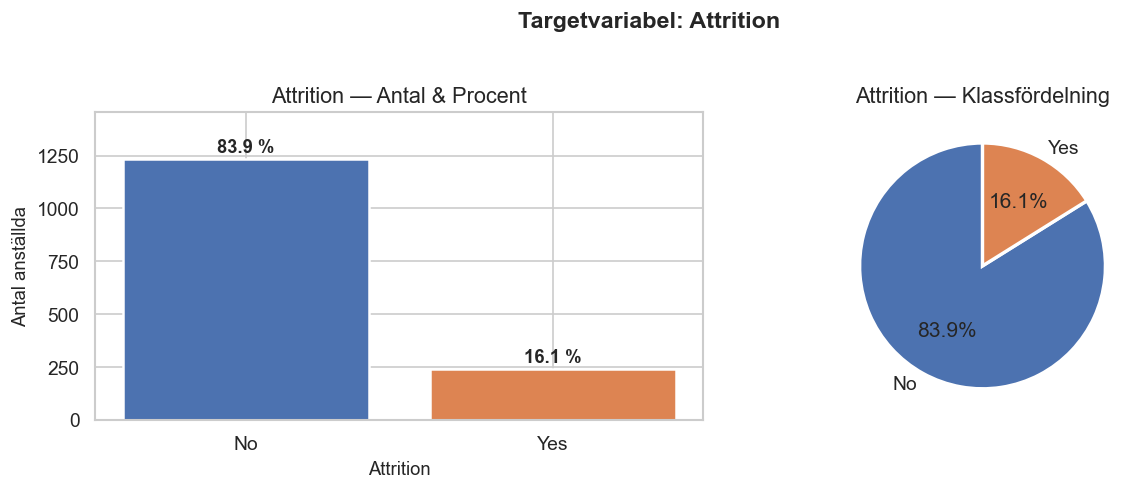

💾 Figur sparad → outputs/figures/eda_01_target_distribution.png


In [4]:
# ── Klassfördelning ────────────────────────────────────────────────────────────
counts = df[TARGET].value_counts()
pcts   = df[TARGET].value_counts(normalize=True) * 100

summary = pd.DataFrame({"Antal": counts, "Procent (%)": pcts.round(2)})
print(summary.to_string())
print(f"\nObalanskvot    : {counts['No'] / counts['Yes']:.1f} : 1  (No : Yes)")
print(f"Minoritetsklass: {pcts['Yes']:.1f} % av alla anställda")

# ── Plot ───────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

ax = axes[0]
bars = ax.bar(counts.index, counts.values,
              color=["#4C72B0", "#DD8452"], edgecolor="white", linewidth=1.5)
for bar, pct in zip(bars, pcts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 15,
            f"{pct:.1f} %", ha="center", va="bottom", fontsize=11, fontweight="bold")
ax.set_title("Attrition — Antal & Procent")
ax.set_xlabel("Attrition")
ax.set_ylabel("Antal anställda")
ax.set_ylim(0, counts.max() * 1.18)

ax2 = axes[1]
ax2.pie(counts.values, labels=counts.index, autopct="%1.1f%%",
        colors=["#4C72B0", "#DD8452"], startangle=90,
        wedgeprops={"edgecolor": "white", "linewidth": 2})
ax2.set_title("Attrition — Klassfördelning")

plt.suptitle("Targetvariabel: Attrition", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figur sparad → outputs/figures/eda_01_target_distribution.png")

**Vad ser vi?**

- **1 233 anställda** stannar kvar (No) — **237 slutar** (Yes)
- Obalanskvoten är **5.2 : 1** — för varje person som slutar finns det
  5 som stannar
- En "dum" modell som alltid svarar "No" skulle få **83.9 % accuracy**
  utan att lära sig någonting alls

Så här hanterar vi obalansen i modellerna:

| Modell | Strategi |
|---|---|
| Decision Tree | `class_weight='balanced'` |
| Random Forest | `class_weight='balanced'` |
| XGBoost | `scale_pos_weight = 1233 / 237 ≈ 5.2` |

Alla splits görs med `stratify=y` så att båda uppsättningarna
(train & test) behåller samma 84/16-fördelning.

## 4. Numeriska features — fördelningar

Nu tittar vi på hur de **numeriska kolumnerna** är fördelade,
och om fördelningen ser annorlunda ut för anställda som slutar
jämfört med de som stannar.

Tänk det som att vi lägger två genomskinliga bilder ovanpå varandra —
en för "Yes" och en för "No" — och ser var de skiljer sig åt.

Vi undersöker:
- Hur ser den övergripande fördelningen ut? (skev, normalfördelad?)
- Finns det features där "Yes" och "No" tydligt **separerar sig**?
- Sådana features kommer troligen vara viktiga för modellen

In [5]:
# ── Separera kolumntyper ───────────────────────────────────────────────────────
exclude = [TARGET, "EmployeeNumber", "EmployeeCount", "Over18", "StandardHours"]

num_cols = [c for c in df.select_dtypes(include=["int64", "float64"]).columns
            if c not in exclude]
cat_cols = [c for c in df.select_dtypes(include="object").columns
            if c not in exclude]

print(f"Numeriska features  ({len(num_cols)}) : {num_cols}")
print(f"\nKategoriska features ({len(cat_cols)}) : {cat_cols}")

Numeriska features  (23) : ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Kategoriska features (7) : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']


**Vad ser vi?**

- **23 numeriska** och **7 kategoriska** features att undersöka
- Notera att flera "numeriska" kolumner egentligen är **ordinala skalor**
  (t.ex. `JobSatisfaction` 1–4, `WorkLifeBalance` 1–4) —
  de är kodade som siffror men representerar egentligen nivåer
- De 7 kategoriska är rena textvärden som one-hot-encodas senare

## 4.1 Histogram — alla numeriska features

Vi plottar ett histogram för varje numerisk feature.
Staplarna är färgade efter `Attrition` — blå för "No", orange för "Yes".

Om de två färgerna **överlappar helt** → featuren skiljer sig inte åt
mellan de som slutar och de som stannar → troligen svag feature.

Om de två färgerna **separerar sig** → featuren är informativ
→ troligen viktig för modellen!

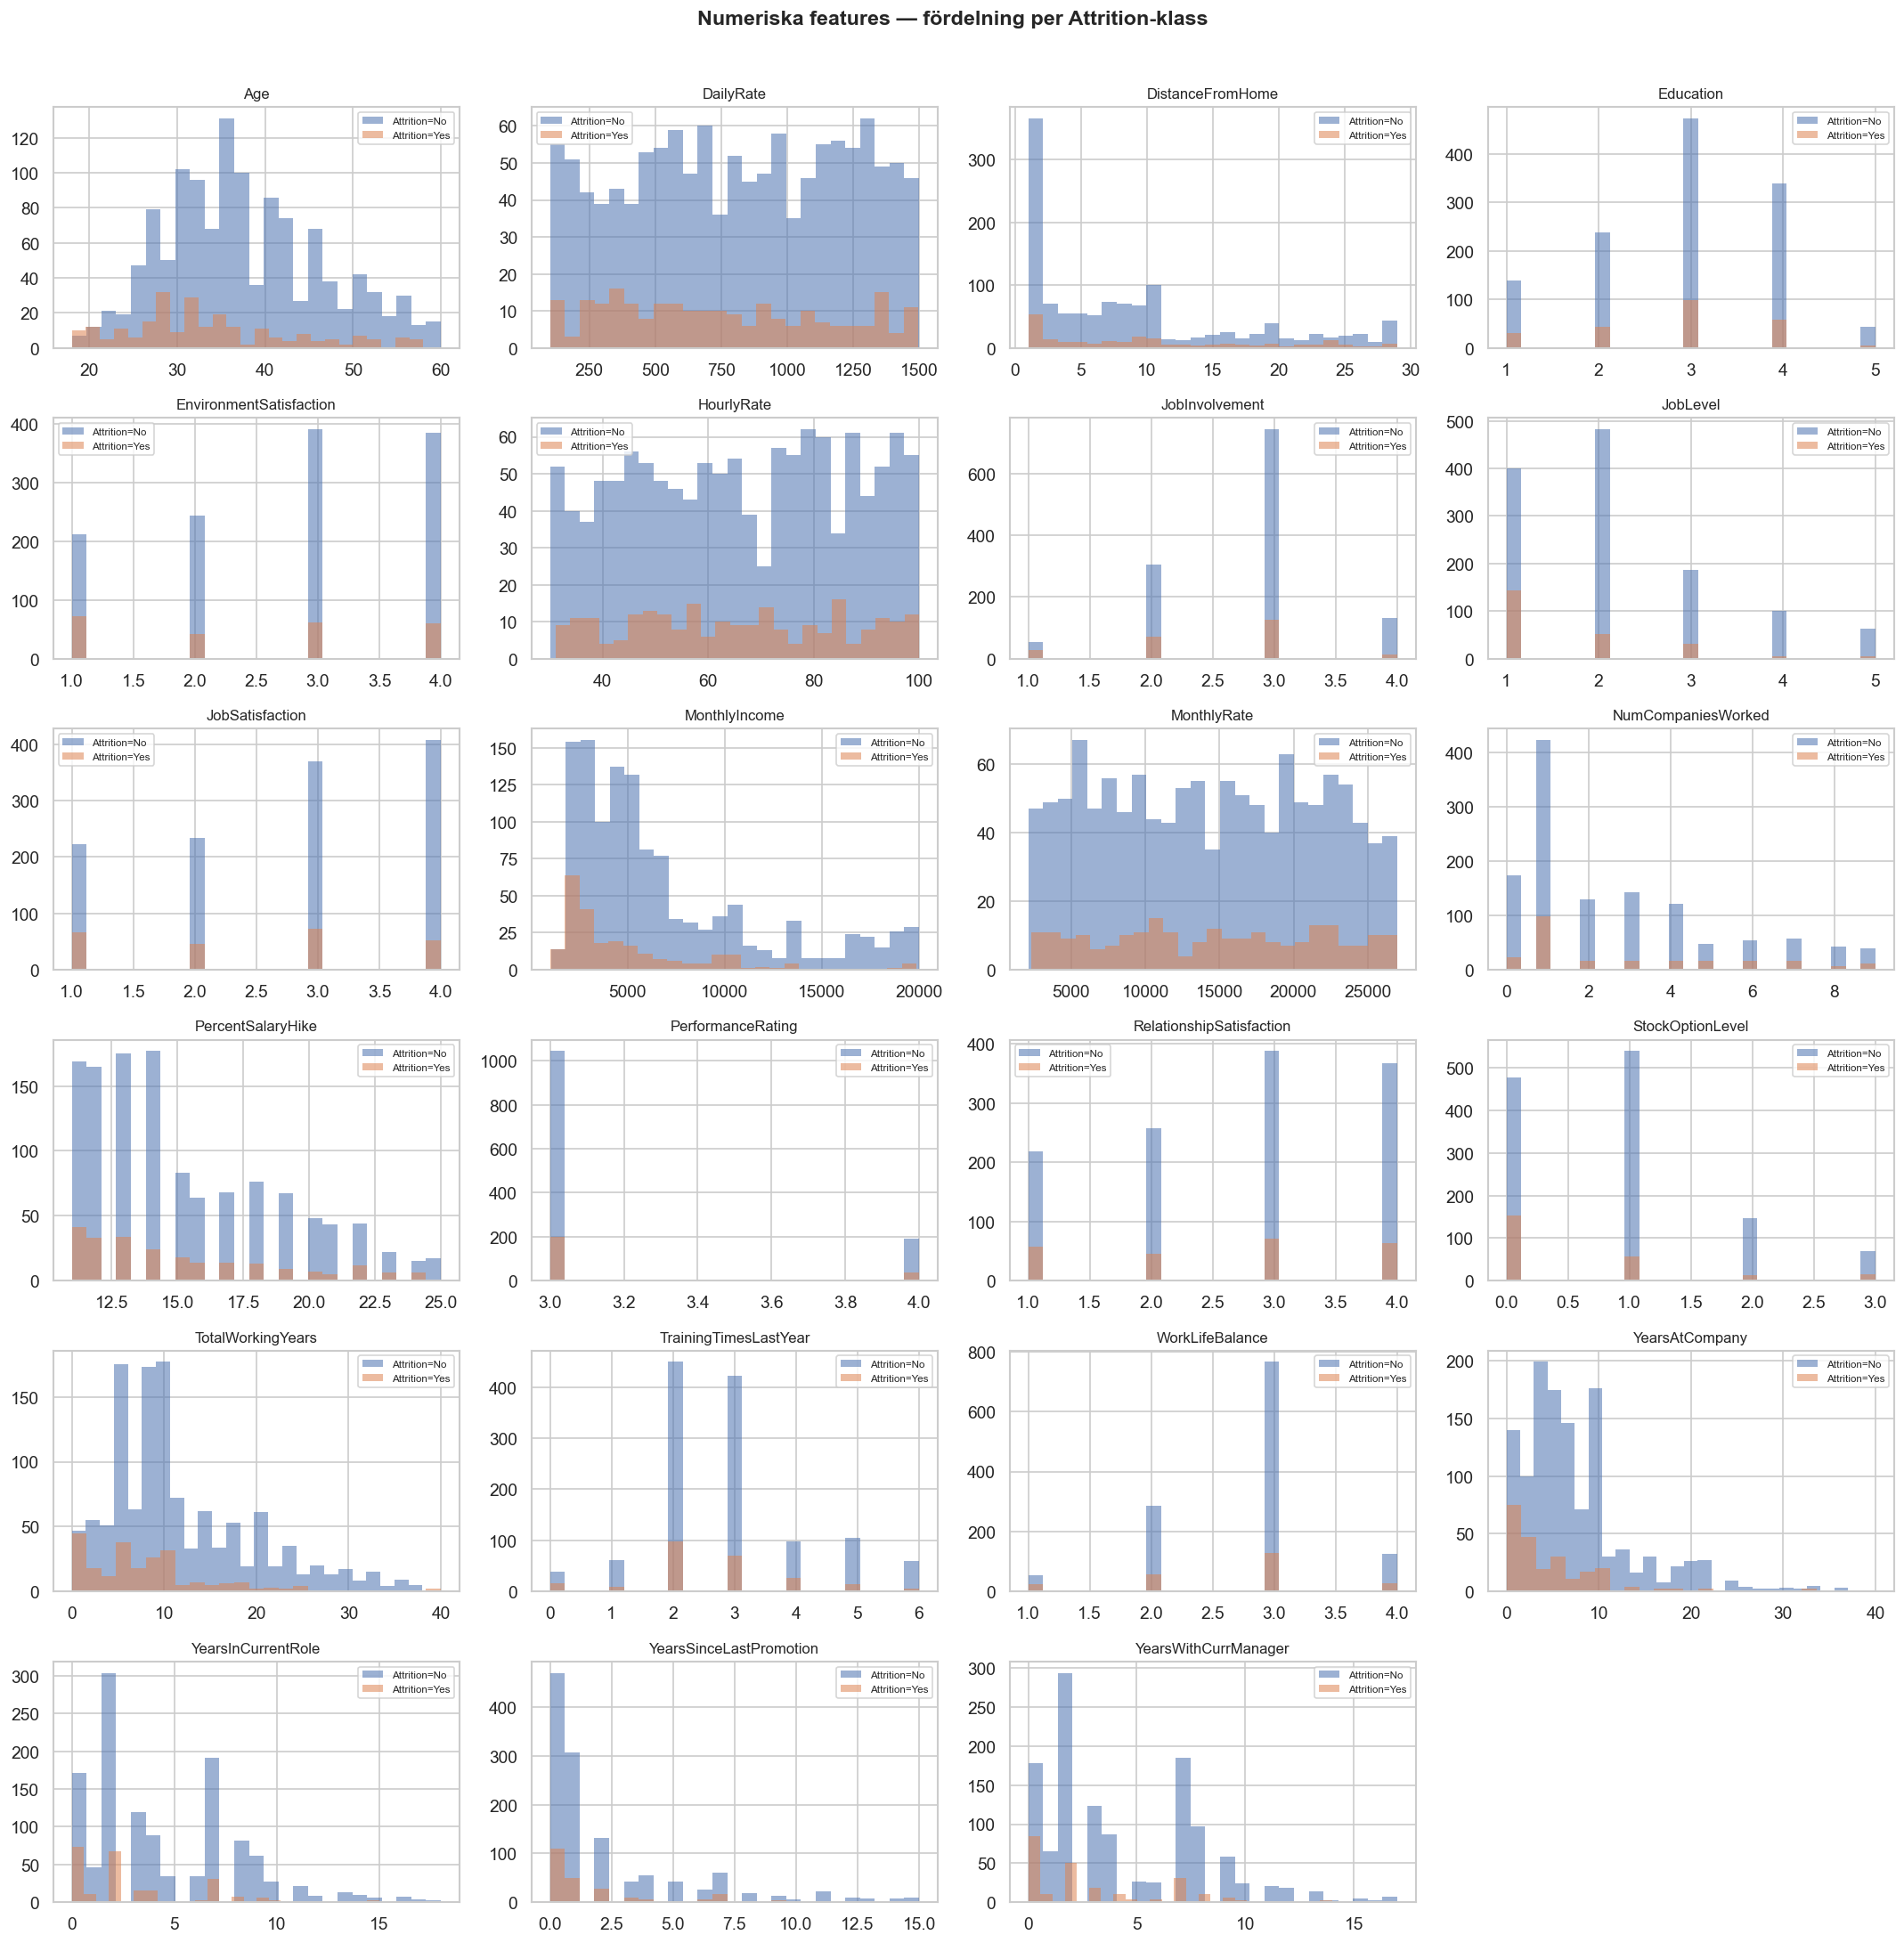

💾 Figur sparad → outputs/figures/eda_02_numerical_histograms.png


In [6]:
# ── Histogram — numeriska features uppdelade på Attrition ─────────────────────
n_cols = 4
n_rows = int(np.ceil(len(num_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    ax = axes[i]
    for label, color in [("No", "#4C72B0"), ("Yes", "#DD8452")]:
        ax.hist(
            df[df[TARGET] == label][col],
            bins=25, alpha=0.55, color=color,
            label=f"Attrition={label}", edgecolor="none"
        )
    ax.set_title(col, fontsize=10)
    ax.set_xlabel("")
    ax.legend(fontsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Numeriska features — fördelning per Attrition-klass",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_02_numerical_histograms.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figur sparad → outputs/figures/eda_02_numerical_histograms.png")

**Vad ser vi?**

Vi letar efter features där det **orange (Yes) och blå (No) separerar sig** —
det är ett tecken på att featuren är viktig för modellen.

**🟠 Starka signaler** — tydlig separation mellan Yes och No:

| Feature | Observation |
|---|---|
| `Age` | Yngre anställda (20–30) slutar i högre grad |
| `MonthlyIncome` | De som slutar tjänar tydligt mindre — orange staplar dominerar lägre löner |
| `JobLevel` | Yes är kraftigt koncentrerat på nivå 1 (lägsta nivån) |
| `StockOptionLevel` | De som slutar har nästan alltid nivå 0 — inga aktieoptioner |
| `TotalWorkingYears` | De som slutar har färre år i arbetslivet totalt |
| `YearsAtCompany` | Yes dominerar 0–2 år — nyanställda slutar mer |
| `YearsInCurrentRole` | Yes koncentrerat kring 0 — nya i rollen slutar mer |
| `YearsWithCurrManager` | Yes koncentrerat kring 0 — ny chef = högre risk |

**🔵 Svaga signaler** — nästan identiska fördelningar:

| Feature | Observation |
|---|---|
| `DailyRate` | Blå och orange överlappar helt — troligen svag feature |
| `HourlyRate` | Samma som DailyRate — liten prediktiv kraft |
| `MonthlyRate` | Ingen tydlig skillnad alls |
| `PercentSalaryHike` | Liknande fördelningar |
| `PerformanceRating` | Bara 2 unika värden (3–4) — nästan ingen variation |

⚠️ **Notera:** Flera features är **skevfördelade** (t.ex. `YearsAtCompany`,
`TotalWorkingYears`) — majoriteten av anställda har relativt få år.
Tree-baserade modeller (Random Forest, XGBoost) hanterar detta bra
utan att vi behöver transformera datan.

## 4.2 Box plots — viktiga numeriska features

Histogram visar fördelning men gör det svårt att jämföra
medelvärden och spridning direkt.

**Box plots** gör det enklare — tänk dig en låda som visar:
- **Linjen i mitten** = medianen (mittenvärdet)
- **Lådans kanter** = 25:e och 75:e percentilen (mitten 50 % av datan)
- **Strecken utanför** = resten av datan (utan extremvärden)
- **Prickarna** = outliers (extremvärden)

Vi fokuserar på de features som visade **starka signaler** i histogrammen.

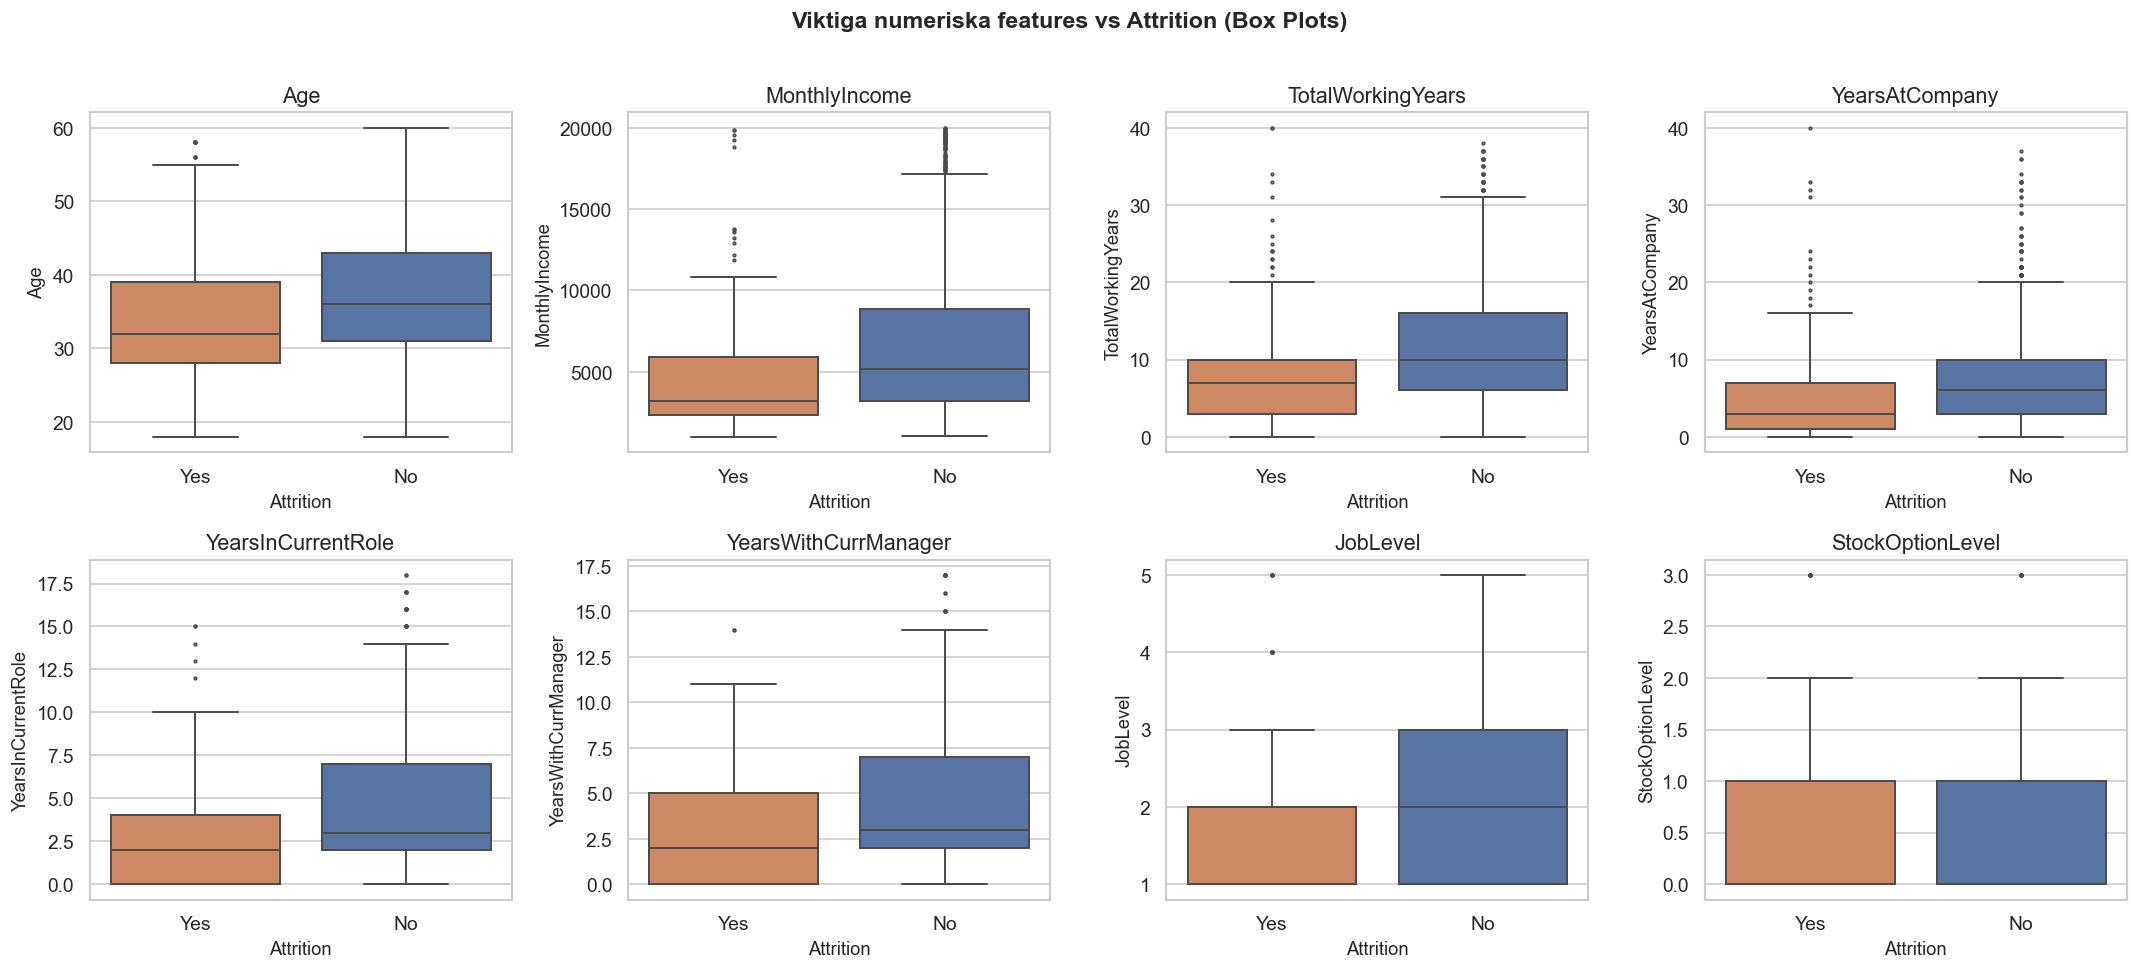

💾 Figur sparad → outputs/figures/eda_03_numerical_boxplots.png


In [7]:
# ── Box plots — starka features ────────────────────────────────────────────────
key_num = [
    "Age", "MonthlyIncome", "TotalWorkingYears",
    "YearsAtCompany", "YearsInCurrentRole",
    "YearsWithCurrManager", "JobLevel", "StockOptionLevel",
]

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()

for i, col in enumerate(key_num):
    sns.boxplot(
        data=df, x=TARGET, y=col,
        palette={"No": "#4C72B0", "Yes": "#DD8452"},
        ax=axes[i], linewidth=1.2,
        flierprops={"marker": ".", "markersize": 3},
    )
    axes[i].set_title(col)
    axes[i].set_xlabel("Attrition")

plt.suptitle("Viktiga numeriska features vs Attrition (Box Plots)",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_03_numerical_boxplots.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figur sparad → outputs/figures/eda_03_numerical_boxplots.png")

**Vad ser vi?**

Box plotsen bekräftar de starka signalerna från histogrammen —
nu kan vi se **medianer och spridning** direkt.

| Feature | Yes (slutar) | No (stannar) | Slutsats |
|---|---|---|---|
| `Age` | Median ~33 år | Median ~37 år | Yngre slutar mer |
| `MonthlyIncome` | Median ~$3 500 | Median ~$5 500 | Lägre lön → högre risk |
| `TotalWorkingYears` | Median ~7 år | Median ~11 år | Mindre erfarenhet → högre risk |
| `YearsAtCompany` | Median ~3 år | Median ~7 år | Nyanställda slutar mer |
| `YearsInCurrentRole` | Median ~2 år | Median ~3 år | Ny i rollen → högre risk |
| `YearsWithCurrManager` | Median ~2 år | Median ~3 år | Ny chef → högre risk |
| `JobLevel` | Median nivå 1 | Median nivå 2 | Lägre jobbnivå → högre risk |
| `StockOptionLevel` | Median nivå 1 | Median nivå 1 | Liten skillnad — svagare signal |

⚠️ **Notera:** `StockOptionLevel` ser lika ut i medianerna men
histogrammet visade att Yes har fler på nivå 0 — box plots
kan dölja den detaljen.

Dessa features förväntas dyka upp högt i **feature importance**
när vi tränar Random Forest och XGBoost.

## 5. Kategoriska features — attrition-andel per kategori

Nu undersöker vi de **7 kategoriska kolumnerna**.

Vi räknar ut **attrition-andelen** (%) för varje kategori —
alltså hur stor andel av personerna i den kategorin som slutar.

Den streckade linjen visar **medelvärdet för hela datasetet (16.1 %)**.
Staplar **över** linjen = högre risk än genomsnittet.
Staplar **under** linjen = lägre risk än genomsnittet.

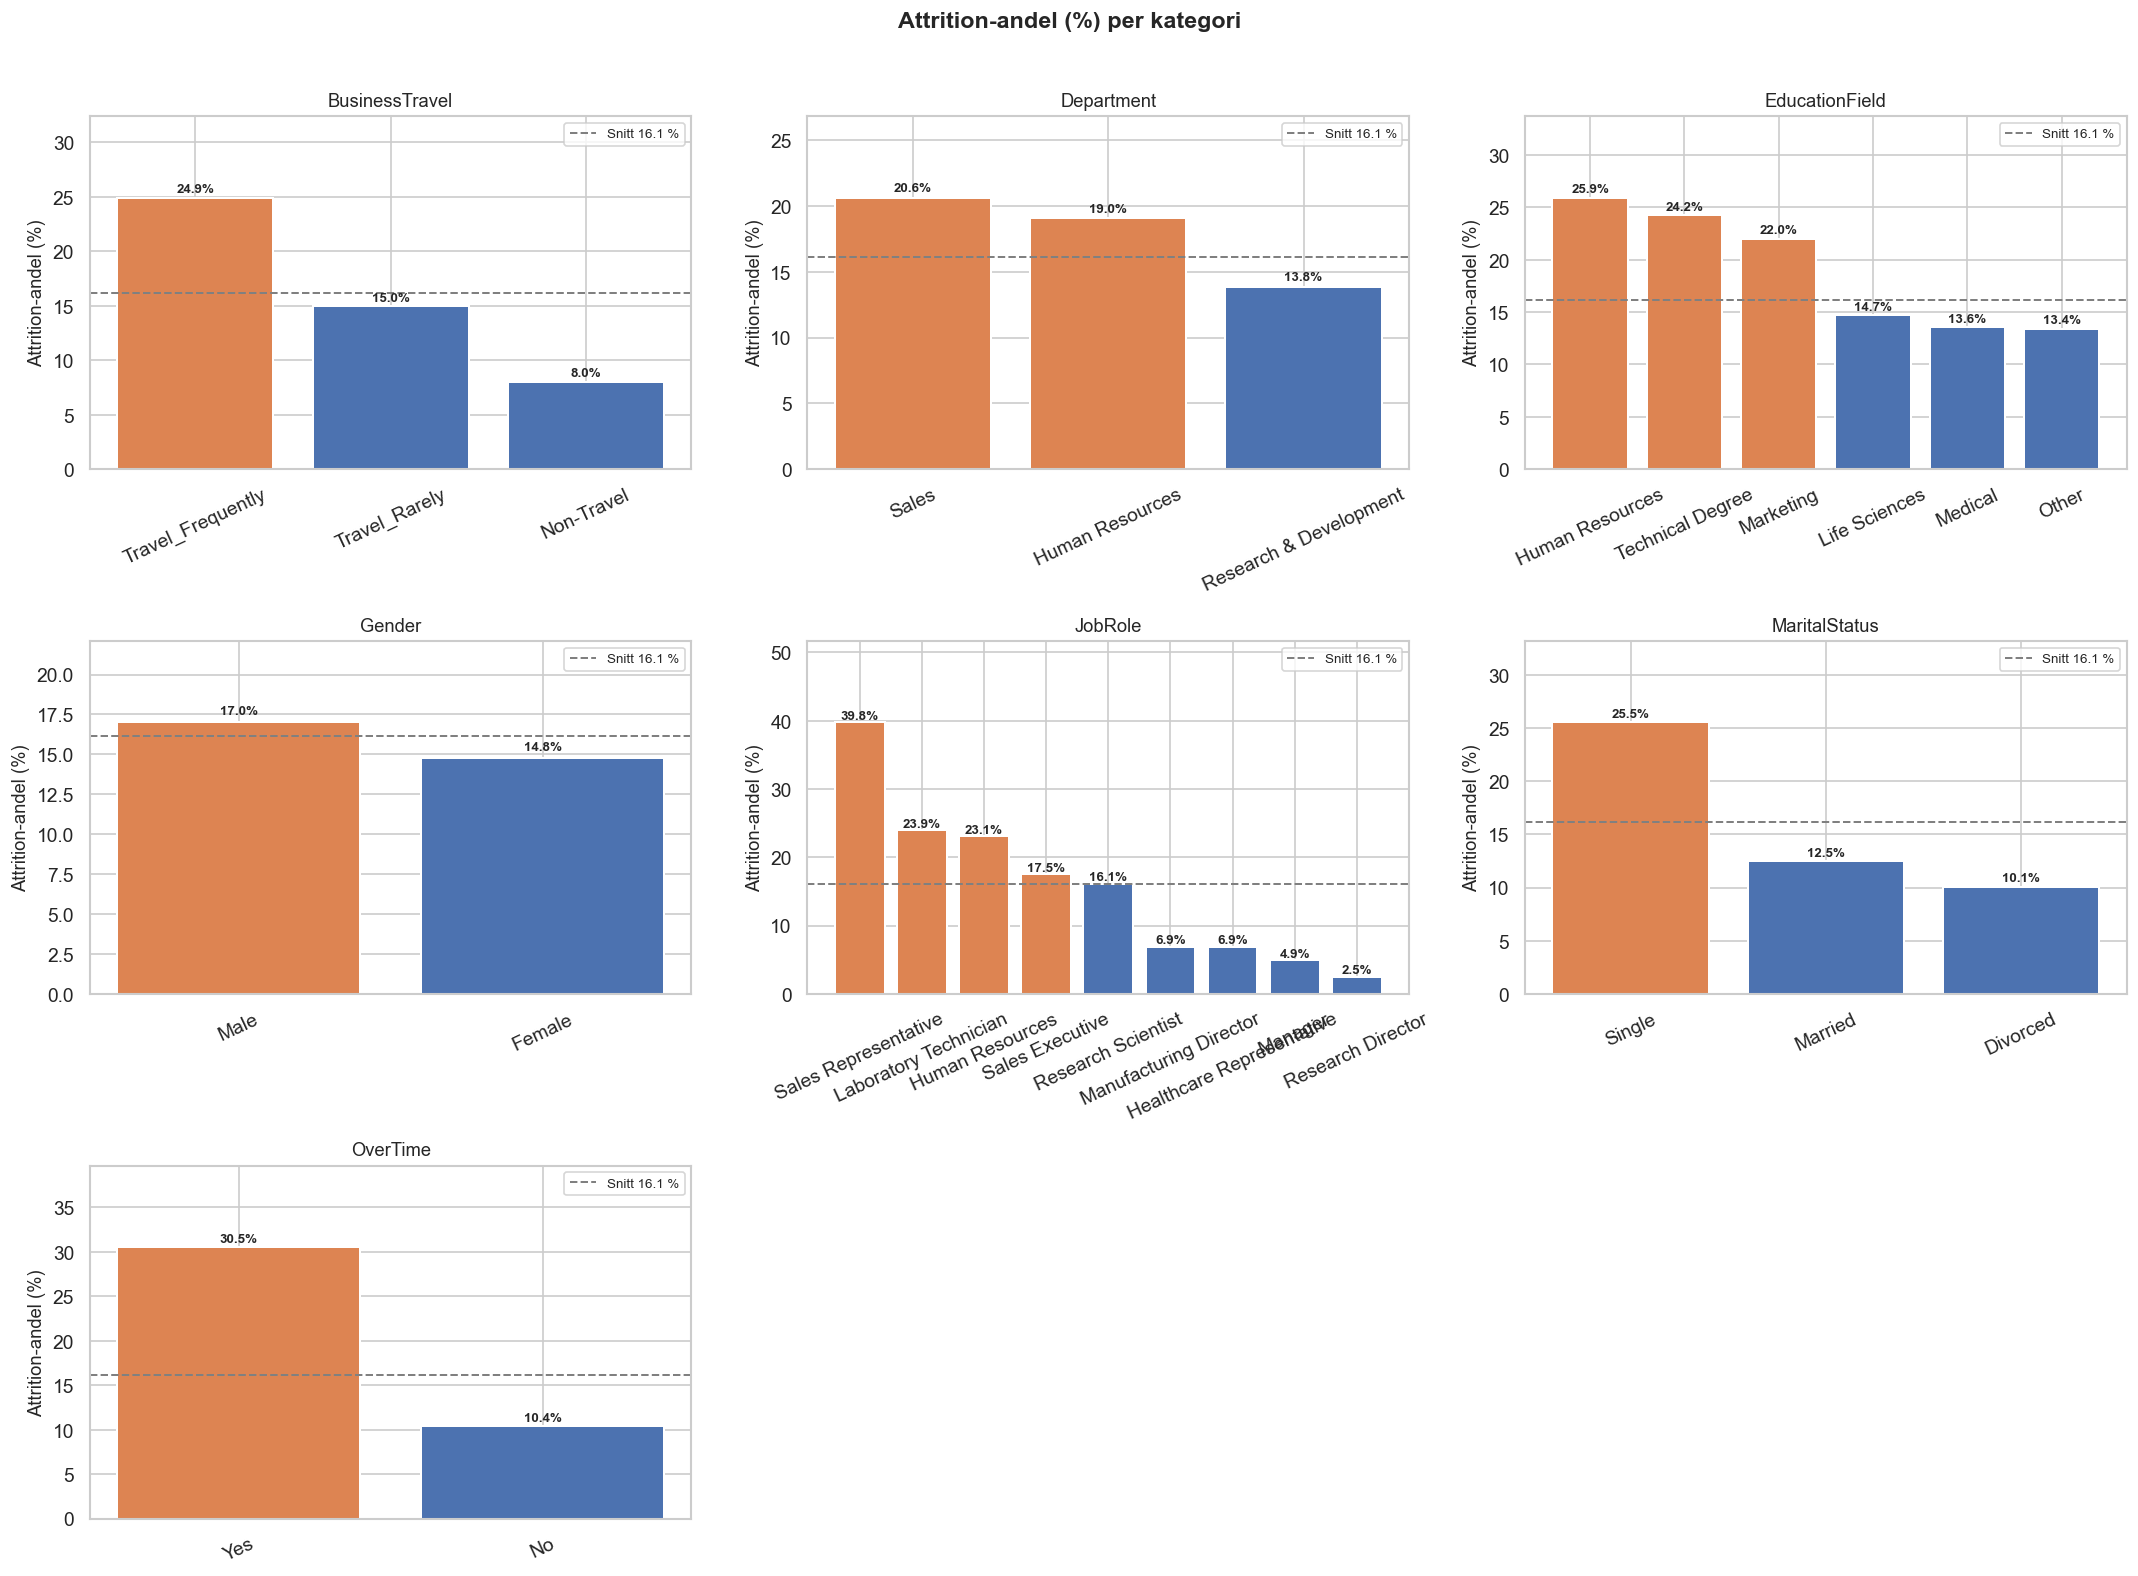

💾 Figur sparad → outputs/figures/eda_04_categorical_attrition_rates.png


In [8]:
# ── Attrition-andel per kategori ───────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(18, 13))
axes = axes.flatten()

baseline = df[TARGET].eq("Yes").mean() * 100

for i, col in enumerate(cat_cols):
    ax = axes[i]
    rate = (
        df.groupby(col)[TARGET]
        .apply(lambda x: (x == "Yes").mean() * 100)
        .sort_values(ascending=False)
    )
    colors = ["#DD8452" if v > baseline else "#4C72B0" for v in rate.values]
    bars = ax.bar(rate.index.astype(str), rate.values,
                  color=colors, edgecolor="white", linewidth=1.2)
    ax.axhline(baseline, color="grey", linestyle="--",
               linewidth=1.2, label=f"Snitt {baseline:.1f} %")
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{bar.get_height():.1f}%", ha="center", fontsize=8, fontweight="bold")
    ax.set_title(col, fontsize=11)
    ax.set_ylabel("Attrition-andel (%)")
    ax.set_ylim(0, rate.max() * 1.3)
    ax.tick_params(axis="x", rotation=25)
    ax.legend(fontsize=8)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Attrition-andel (%) per kategori",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_04_categorical_attrition_rates.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figur sparad → outputs/figures/eda_04_categorical_attrition_rates.png")

**Vad ser vi?**

Staplarna som är **orange** ligger över snittet (16.1 %) — högre risk.
Staplarna som är **blå** ligger under snittet — lägre risk.

| Feature | Högst risk | Lägst risk | Spread |
|---|---|---|---|
| `OverTime` | Yes = **30.5 %** | No = 10.4 % | 20.1 pp |
| `JobRole` | Sales Representative = **39.8 %** | Research Director = 2.5 % | 37.3 pp |
| `BusinessTravel` | Travel_Frequently = **24.9 %** | Non-Travel = 8.0 % | 16.9 pp |
| `MaritalStatus` | Single = **25.5 %** | Divorced = 10.1 % | 15.4 pp |
| `EducationField` | Human Resources = **25.9 %** | Other = 13.4 % | 12.5 pp |
| `Department` | Sales = **20.6 %** | R&D = 13.8 % | 6.8 pp |
| `Gender` | Male = **17.0 %** | Female = 14.8 % | 2.2 pp |

**Viktigaste fynd:**

- 🔴 **`OverTime`** är den starkaste kategoriska signalen — anställda som
  jobbar övertid slutar i nästan **3× högre takt** än de som inte gör det
- 🔴 **`Sales Representative`** har nästan **40 %** attrition-andel —
  mer än varannan säljare på 5 slutar
- 🔴 **`Travel_Frequently`** ökar risken markant jämfört med Non-Travel
- 🔴 **`Single`** slutar mer — troligen yngre och mer rörliga på arbetsmarknaden
- 🟢 **`Gender`** visar minimal skillnad (2.2 pp) — svag feature
- 🟢 **`Research Director`** och **`Manager`** har mycket låg attrition —
  seniora roller stannar kvar

## 6. Korrelationsmatris — samband mellan numeriska features

Nu undersöker vi hur de numeriska featuresen **korrelerar med varandra**.

Korrelation mäts mellan -1 och 1:
- **Nära 1** = starkt positivt samband (båda ökar tillsammans)
- **Nära -1** = starkt negativt samband (en ökar, den andra minskar)
- **Nära 0** = inget samband alls

Vi visar bara den **undre triangeln** — den övre är en spegelvänd
kopia och ger ingen ny information.

⚠️ Hög korrelation mellan **features** (inte mot target) kallas
**multikollinearitet**. Det är inget stort problem för träd-baserade
modeller som Random Forest och XGBoost, men bra att känna till.

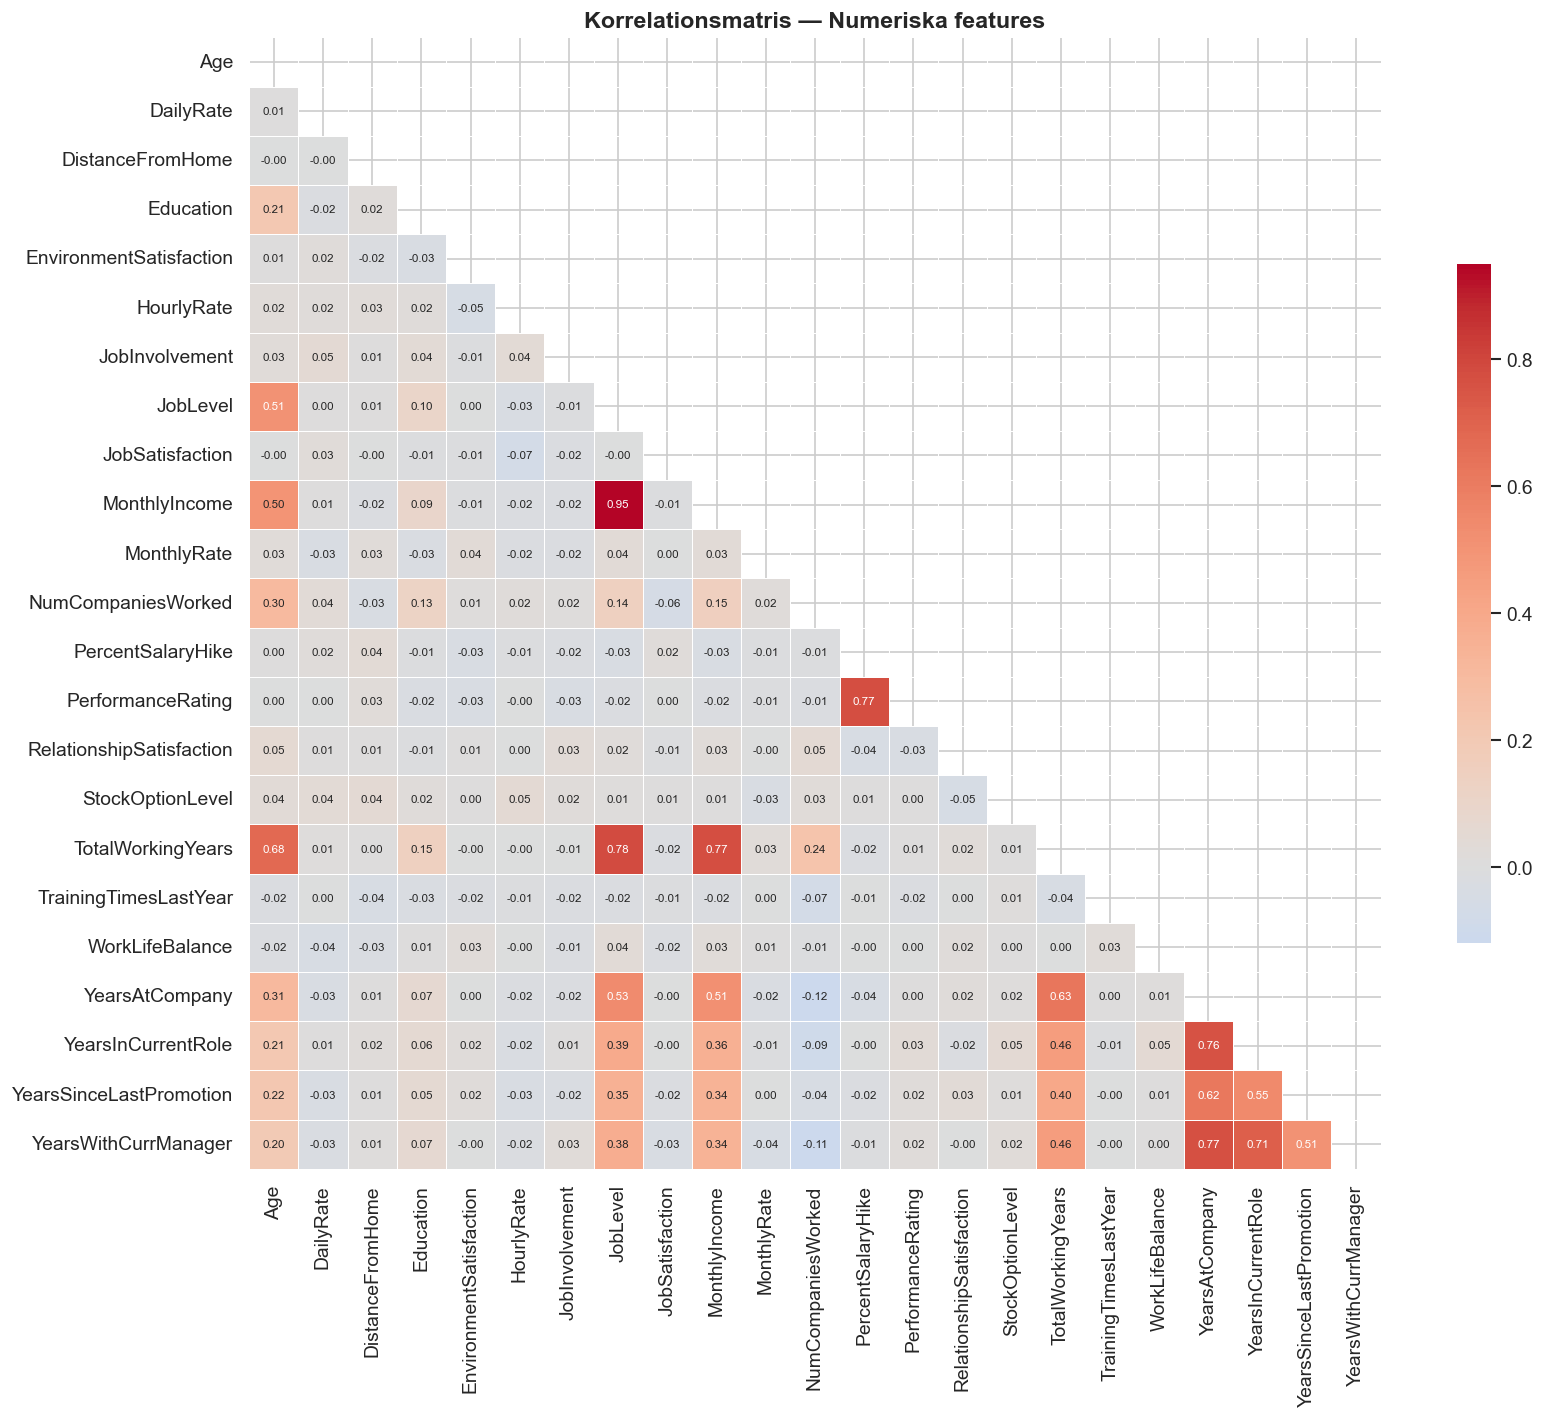

💾 Figur sparad → outputs/figures/eda_05_correlation_matrix.png


In [9]:
# ── Korrelationsmatris ─────────────────────────────────────────────────────────
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))  # dölj övre triangeln

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(
    corr, mask=mask, annot=True, fmt=".2f",
    cmap="coolwarm", center=0, linewidths=0.4,
    annot_kws={"size": 7}, ax=ax, square=True,
    cbar_kws={"shrink": 0.6},
)
ax.set_title("Korrelationsmatris — Numeriska features",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{FIGURES_DIR}/eda_05_correlation_matrix.png",
            dpi=150, bbox_inches="tight")
plt.show()
print("💾 Figur sparad → outputs/figures/eda_05_correlation_matrix.png")

**Vad ser vi?**

De mörkröda rutorna visar **starka positiva korrelationer** — det är
features som hänger tätt ihop med varandra.

**🔴 Starka korrelationer (> 0.60):**

| Feature A | Feature B | Korrelation | Förklaring |
|---|---|---|---|
| `JobLevel` | `MonthlyIncome` | **0.95** | Högre jobbnivå = högre lön — ingen överraskning |
| `TotalWorkingYears` | `JobLevel` | **0.78** | Mer erfarenhet → högre position |
| `TotalWorkingYears` | `MonthlyIncome` | **0.77** | Mer erfarenhet → högre lön |
| `PercentSalaryHike` | `PerformanceRating` | **0.77** | Bra prestation → högre löneökning |
| `YearsWithCurrManager` | `YearsAtCompany` | **0.77** | Stannar länge = samma chef länge |
| `YearsInCurrentRole` | `YearsWithCurrManager` | **0.71** | Stannar i rollen = stannar med chefen |
| `YearsAtCompany` | `YearsInCurrentRole` | **0.76** | Hänger naturligt ihop |
| `Age` | `TotalWorkingYears` | **0.68** | Äldre = fler år i arbetslivet |
| `Age` | `JobLevel` | **0.51** | Äldre tenderar ha högre position |

**Vad betyder detta för modellen?**

Detta kallas **multikollinearitet** — flera features mäter
i princip samma sak på olika sätt.

✅ **Random Forest och XGBoost hanterar detta bra** — de väljer
automatiskt den mest informativa featuren vid varje split.

⚠️ För linjära modeller (t.ex. Logistic Regression) hade detta
varit ett större problem och krävt att vi tagit bort några features.

**🔵 De flesta par har korrelation nära 0** — majoriteten av
featuresen är relativt oberoende av varandra, vilket är bra.

## 7. Sammanfattning — Viktigaste EDA-fynd

Nu samlar vi ihop allt vi lärt oss. Det här är grunden som alla
modellbeslut i kommande notebooks bygger på.

In [10]:
# ── Sammanfattningstabell ──────────────────────────────────────────────────────
summary_data = {
    "#": [1, 2, 3, 4, 5, 6, 7, 8],
    "Fynd": [
        "Inga saknade värden",
        "3 konstanta kolumner",
        "Klassobalans 84 % / 16 %",
        "OverTime — starkaste kategoriska signalen",
        "MonthlyIncome & JobLevel — starka numeriska signaler",
        "Nyanställda slutar mer",
        "Hög multikollinearitet i karriär-features",
        "Gender — svag signal",
    ],
    "Detalj": [
        "Datasetet är komplett — ingen imputation behövs",
        "EmployeeCount, Over18, StandardHours tas bort i clean_and_encode()",
        "Naiv modell → 84 % accuracy utan att lära sig något",
        "30.5 % vs 10.4 % — övertid nästan 3× högre risk",
        "Lägre lön och lägre jobbnivå = tydligt högre attrition",
        "YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager låga för Yes",
        "JobLevel ↔ MonthlyIncome = 0.95 — träd hanterar detta bra",
        "Endast 2.2 pp skillnad mellan Male/Female",
    ],
    "Åtgärd": [
        "Ingen",
        "Droppas i preprocessing",
        "class_weight, scale_pos_weight, stratified split, F1 & ROC-AUC",
        "Förväntas topp-3 i feature importance",
        "Förväntas högt i feature importance",
        "Förväntas högt i feature importance",
        "Inget — RF & XGBoost robust mot detta",
        "Låg prioritet som feature",
    ],
}

summary_df = pd.DataFrame(summary_data).set_index("#")
display(summary_df.style.set_properties(**{"text-align": "left"}))
print("\n✅ EDA klar — redo för modellering!")

,Fynd,Detalj,Åtgärd
#,,,
1,Inga saknade värden,Datasetet är komplett — ingen imputation behövs,Ingen
2,3 konstanta kolumner,"EmployeeCount, Over18, StandardHours tas bort i clean_and_encode()",Droppas i preprocessing
3,Klassobalans 84 % / 16 %,Naiv modell → 84 % accuracy utan att lära sig något,"class_weight, scale_pos_weight, stratified split, F1 & ROC-AUC"
4,OverTime — starkaste kategoriska signalen,30.5 % vs 10.4 % — övertid nästan 3× högre risk,Förväntas topp-3 i feature importance
5,MonthlyIncome & JobLevel — starka numeriska signaler,Lägre lön och lägre jobbnivå = tydligt högre attrition,Förväntas högt i feature importance
6,Nyanställda slutar mer,"YearsAtCompany, YearsInCurrentRole, YearsWithCurrManager låga för Yes",Förväntas högt i feature importance
7,Hög multikollinearitet i karriär-features,JobLevel ↔ MonthlyIncome = 0.95 — träd hanterar detta bra,Inget — RF & XGBoost robust mot detta
8,Gender — svag signal,Endast 2.2 pp skillnad mellan Male/Female,Låg prioritet som feature



✅ EDA klar — redo för modellering!


**Vad ser vi?**

Tabellen samlar de **8 viktigaste fynden** från hela EDA:n.

De tre viktigaste att ta med sig in i modelleringen:

1. **Klassobalansen** (fynd 3) — påverkar alla modellval vi gör
2. **OverTime, MonthlyIncome, JobLevel** (fynd 4 & 5) — förväntas
   dominera feature importance i RF och XGBoost
3. **Multikollineariteten** (fynd 7) — inget problem för våra modeller,
   men viktigt att förstå varför vi ser liknande features högt upp

---

**Nästa steg:** `02_decision_tree.ipynb` — Baseline-modell med ett
enkelt beslutsträd. Vi ser hur långt vi kommer utan ensemblemetoder.